In [5]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rerkki/data-analytics-ml/refs/heads/main/datasets/Student_Performance.csv", encoding='latin-1')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Preparation
First, convert the 'Extracurricular Activities' column into numerical format (0 for 'No', 1 for 'Yes') using `map` function. Then, define the independent variables (features) and the dependent variable (target).

In [6]:
# Convert 'Extracurricular Activities' to numerical (0/1)
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'No': 0, 'Yes': 1})

# Define independent variables (X) and dependent variable (y)
X = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']]
y = df['Performance Index']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5



Target (y) head:


,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


### 2. Splitting the Data
Split the dataset into training and testing sets to evaluate the model's performance on unseen data. Use 80% of the data for training and 20% for testing.

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (8000, 5), (8000,)
Testing set shape: (2000, 5), (2000,)


### 3. Building and Training the Multiple Linear Regression Model
Next, create and train a Linear Regression model using the training data.

In [10]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### 4. Evaluating the Model
Finally, evaluate the model's performance on the test set using metrics like Mean Squared Error (MSE) and R-squared (R2).

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display model coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients)
print(f"Intercept: {model.intercept_:.2f}")

Mean Squared Error (MSE): 4.08
R-squared (R2): 0.99


,Feature,Coefficient
0,Hours Studied,2.852484
1,Previous Scores,1.016988
2,Extracurricular Activities,0.608617
3,Sleep Hours,0.476941
4,Sample Question Papers Practiced,0.191831


Intercept: -33.92


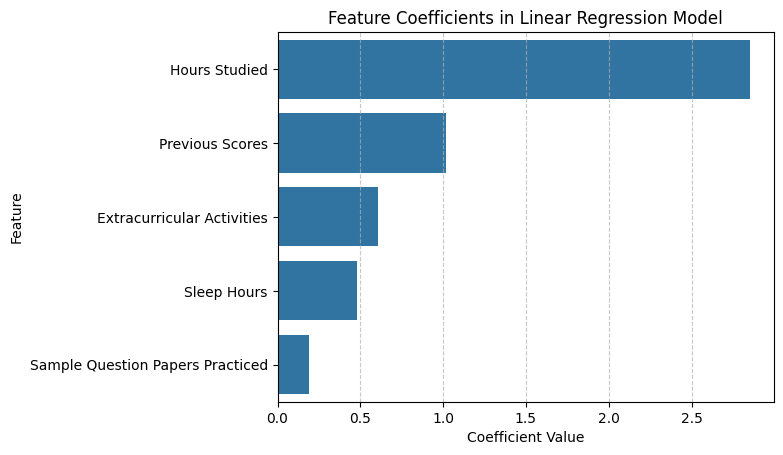

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x='Coefficient', y='Feature', data=coefficients.sort_values(by='Coefficient', ascending=False))
plt.title('Feature Coefficients in Linear Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 5. Visualizing Predictions
Visualize the actual vs. predicted values to see how well our model performs.

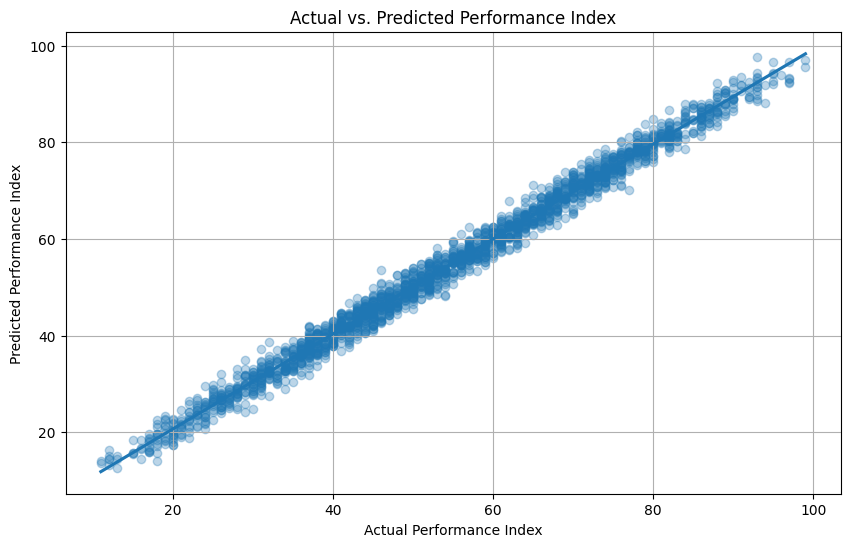

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs. Predicted Performance Index')
plt.grid(True)
plt.show()

### 6. Correlation Map
Let's visualize the correlation between all the variables in the dataset to understand their relationships.

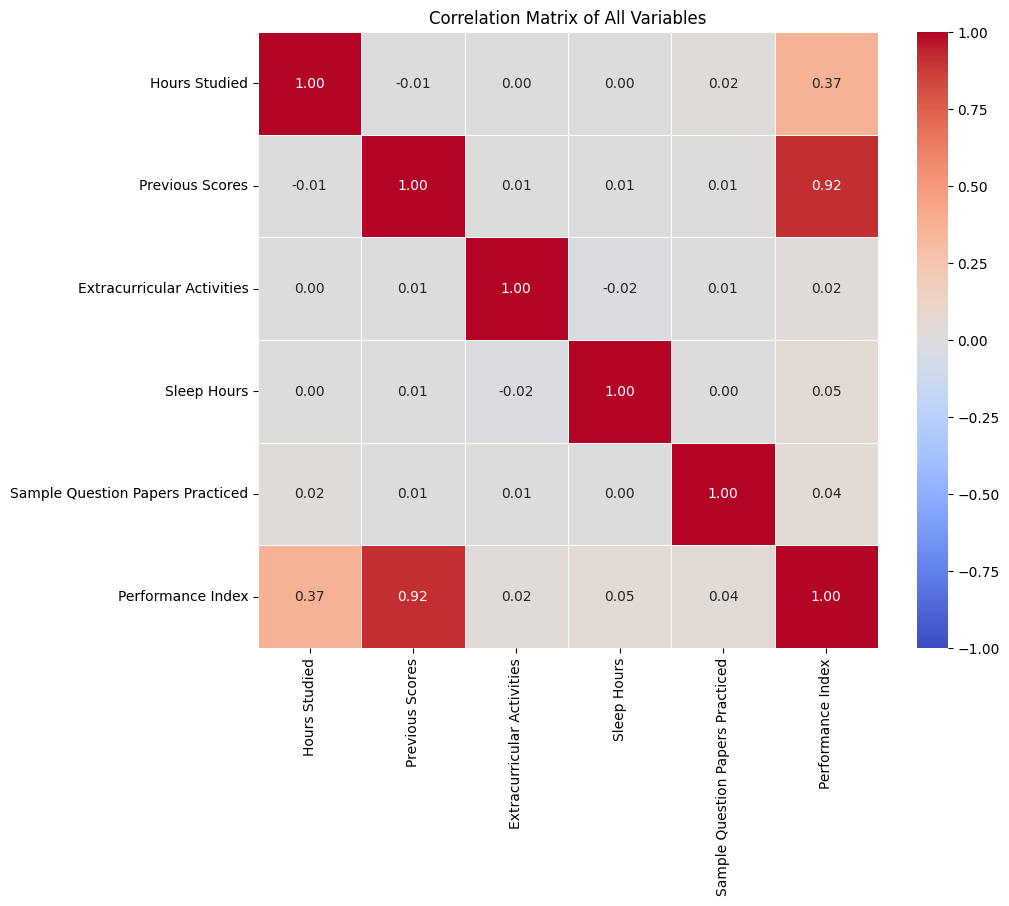

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Determine the maximum absolute correlation for symmetrical color scaling
max_corr_abs = correlation_matrix.abs().max().max()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, center=0, vmin=-max_corr_abs, vmax=max_corr_abs)
plt.title('Correlation Matrix of All Variables')
plt.show()

**Comparison:**

Key Influencers: Both analyses agree that 'Previous Scores' and 'Hours Studied' are the most significant factors influencing 'Performance Index'.

**Magnitude of Impact (Correlation vs. Regression):**

Correlation Map: Shows 'Previous Scores' having a very high positive correlation (0.91) with 'Performance Index', suggesting a strong direct linear relationship. 'Hours Studied' also has a positive correlation (0.37), but it's less pronounced than 'Previous Scores'.
Regression Coefficients: While 'Previous Scores' has a strong positive coefficient (1.02), 'Hours Studied' actually has the largest positive coefficient (2.85). This indicates that, when controlling for all other variables in the model, an increase in 'Hours Studied' has a stronger independent impact on 'Performance Index' than 'Previous Scores'.
Interpretation: The correlation map provides a bivariate view (how two variables move together). The regression coefficients, on the other hand, show the unique contribution of each independent variable to the dependent variable, assuming all other independent variables are held constant. This difference explains why 'Previous Scores' has a higher raw correlation but 'Hours Studied' has a higher regression coefficient.

**Short Summary:**

The correlation map effectively highlights strong bivariate relationships, with 'Previous Scores' appearing as the strongest correlate to 'Performance Index'. However, the multi-linear regression model reveals that 'Hours Studied' exerts the most significant independent influence on 'Performance Index' when considering all predictor variables simultaneously. This implies that while 'Previous Scores' are highly associated with performance, 'Hours Studied' is a more direct and potent lever for improving performance within this multivariate context.

The correlation map of all variables has been successfully generated! This heatmap visually represents the strength and direction of the linear relationship between each pair of variables in your dataset.

Colors: The 'coolwarm' colormap is used, where warmer colors (reds) indicate strong positive correlations, cooler colors (blues) indicate strong negative correlations, and shades around white/light colors indicate weak or no correlation.

Values: The numbers within each cell (formatted to two decimal places) represent the Pearson correlation coefficient.
A value close to 1.00 (e.g., Previous Scores and Performance Index at 0.91) means a strong positive relationship: as one variable increases, the other tends to increase proportionally.
A value close to -1.00 would mean a strong negative relationship (as one increases, the other decreases).
A value around 0.00 indicates a very weak or no linear relationship.
From this map, you can clearly see that 'Previous Scores' has a very strong positive correlation with 'Performance Index' (0.91), which aligns with our intuition that past performance is a significant predictor of future performance. 'Hours Studied' also shows a positive correlation (0.37) with 'Performance Index', though less strong than 'Previous Scores'. The other variables ('Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced') show weaker correlations with 'Performance Index', but still positive.